In [84]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [85]:
data  = pd.read_csv('datasets/movie_metadata.csv')
data.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [86]:
data.shape

(5043, 28)

In [87]:
data.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='object')

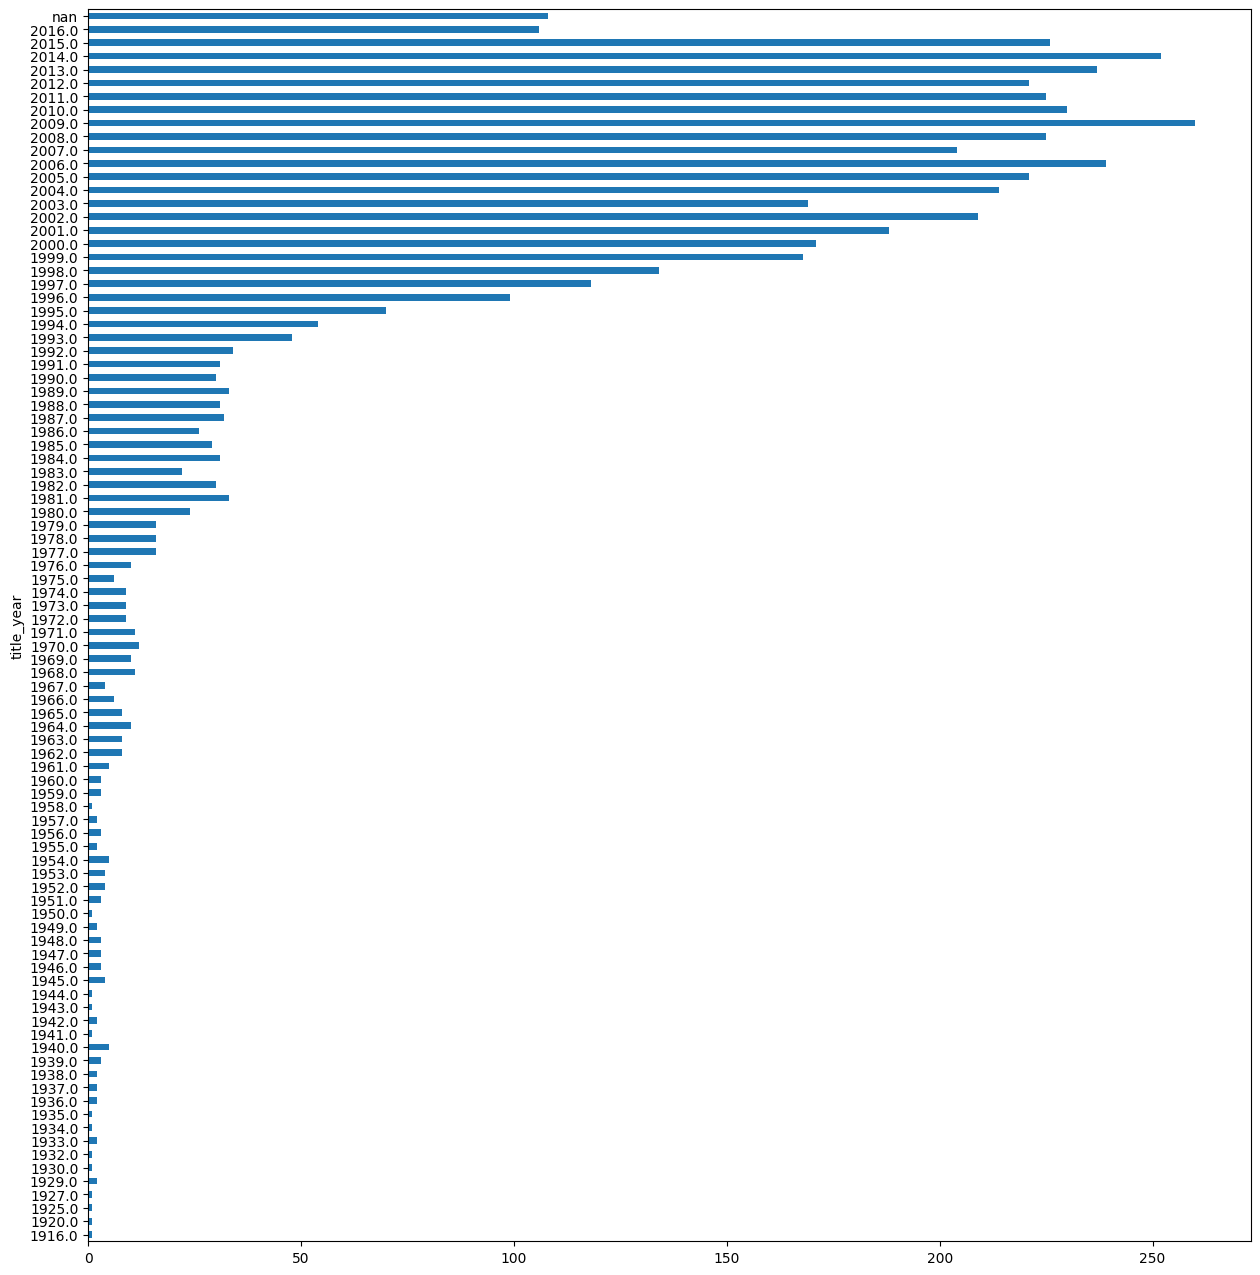

In [88]:
# Data till 2016 only
data.title_year.value_counts(dropna=False).sort_index().plot(kind='barh', figsize=(15,16))
plt.show()

In [89]:
# Features for recommendation
data = data.loc[:,['director_name', 'actor_1_name', 'actor_2_name', 'actor_3_name', 'genres',
                'duration', 'movie_title', 'language', 'imdb_score']]

In [90]:
data.head()

,director_name,actor_1_name,actor_2_name,actor_3_name,genres,duration,movie_title,language,imdb_score
0,James Cameron,CCH Pounder,Joel David Moore,Wes Studi,Action|Adventure|Fantasy|Sci-Fi,178.0,Avatar,English,7.9
1,Gore Verbinski,Johnny Depp,Orlando Bloom,Jack Davenport,Action|Adventure|Fantasy,169.0,Pirates of the Caribbean: At World's End,English,7.1
2,Sam Mendes,Christoph Waltz,Rory Kinnear,Stephanie Sigman,Action|Adventure|Thriller,148.0,Spectre,English,6.8
3,Christopher Nolan,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,Action|Thriller,164.0,The Dark Knight Rises,English,8.5
4,Doug Walker,Doug Walker,Rob Walker,NaN,Documentary,NaN,Star Wars: Episode VII - The Force Awakens ...,NaN,7.1


In [91]:
data.isna().sum()

director_name    104
actor_1_name       7
actor_2_name      13
actor_3_name      23
genres             0
duration          15
movie_title        0
language          14
imdb_score         0
dtype: int64

In [92]:
data['actor_1_name'] = data['actor_1_name'].replace(np.nan, 'unknown')
data['actor_2_name'] = data['actor_2_name'].replace(np.nan, 'unknown')
data['actor_3_name'] = data['actor_3_name'].replace(np.nan, 'unknown')
data['director_name'] = data['director_name'].replace(np.nan, 'unknown')
data['genres'] = data['genres'].replace(np.nan, 'unknown')
data['language'] = data['language'].replace(np.nan, 'unknown')
data['duration'] = data['duration'].replace(np.nan, 0)

In [93]:
data.head()

,director_name,actor_1_name,actor_2_name,actor_3_name,genres,duration,movie_title,language,imdb_score
0,James Cameron,CCH Pounder,Joel David Moore,Wes Studi,Action|Adventure|Fantasy|Sci-Fi,178.0,Avatar,English,7.9
1,Gore Verbinski,Johnny Depp,Orlando Bloom,Jack Davenport,Action|Adventure|Fantasy,169.0,Pirates of the Caribbean: At World's End,English,7.1
2,Sam Mendes,Christoph Waltz,Rory Kinnear,Stephanie Sigman,Action|Adventure|Thriller,148.0,Spectre,English,6.8
3,Christopher Nolan,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,Action|Thriller,164.0,The Dark Knight Rises,English,8.5
4,Doug Walker,Doug Walker,Rob Walker,unknown,Documentary,0.0,Star Wars: Episode VII - The Force Awakens ...,unknown,7.1


In [95]:
data['genres'] = data['genres'].str.replace('|', ' ')

In [96]:
data.head()

,director_name,actor_1_name,actor_2_name,actor_3_name,genres,duration,movie_title,language,imdb_score
0,James Cameron,CCH Pounder,Joel David Moore,Wes Studi,Action Adventure Fantasy Sci-Fi,178.0,Avatar,English,7.9
1,Gore Verbinski,Johnny Depp,Orlando Bloom,Jack Davenport,Action Adventure Fantasy,169.0,Pirates of the Caribbean: At World's End,English,7.1
2,Sam Mendes,Christoph Waltz,Rory Kinnear,Stephanie Sigman,Action Adventure Thriller,148.0,Spectre,English,6.8
3,Christopher Nolan,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,Action Thriller,164.0,The Dark Knight Rises,English,8.5
4,Doug Walker,Doug Walker,Rob Walker,unknown,Documentary,0.0,Star Wars: Episode VII - The Force Awakens ...,unknown,7.1


In [98]:
data['movie_title'] = data['movie_title'].str.lower()

In [99]:
data.head()

,director_name,actor_1_name,actor_2_name,actor_3_name,genres,duration,movie_title,language,imdb_score
0,James Cameron,CCH Pounder,Joel David Moore,Wes Studi,Action Adventure Fantasy Sci-Fi,178.0,avatar,English,7.9
1,Gore Verbinski,Johnny Depp,Orlando Bloom,Jack Davenport,Action Adventure Fantasy,169.0,pirates of the caribbean: at world's end,English,7.1
2,Sam Mendes,Christoph Waltz,Rory Kinnear,Stephanie Sigman,Action Adventure Thriller,148.0,spectre,English,6.8
3,Christopher Nolan,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,Action Thriller,164.0,the dark knight rises,English,8.5
4,Doug Walker,Doug Walker,Rob Walker,unknown,Documentary,0.0,star wars: episode vii - the force awakens ...,unknown,7.1


In [100]:
data['movie_title'][0]

'avatar\xa0'

In [101]:
data['movie_title'] = data['movie_title'].apply(lambda x : x[:-1])

In [102]:
data['movie_title'][0]

'avatar'

In [103]:
data.to_csv('datasets/data1.csv', index=False)